In [ ]:
### Import libraries/dataset
!pip install catboost
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
df = pd.read_csv('https://raw.githubusercontent.com/PandaKnee/Rod-Pump-Failure-Analysis/refs/heads/main/postFS_df.csv')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.2 MB/s eta 0:00:00


In [ ]:
### Preprocessing
df = df[df['FAILED'] == 1] #use only censored data
df.drop(['UWI','tbguid','lifetime_start','FAILURETYPE'], axis = 1, inplace = True)
X = df.drop(['FAILED','lifetime_duration_days'], axis = 1)
y = df['lifetime_duration_days']
cat = ['bha_configuration', 'ROUTE']

#stratify by quartiles
y_bins = pd.qcut(y, q=5, labels=False, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state = 21,stratify=y_bins)

In [ ]:
### Grid Search test
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import make_scorer, mean_squared_error
# from catboost import CatBoostRegressor

# # Define evaluation metric for GridSearchCV
# def rmse_metric(y_true, y_pred):
#     return np.sqrt(mean_squared_error(y_true, y_pred))

# # Wrap CatBoost into a callable object for GridSearchCV compatibility
# model = CatBoostRegressor(cat_features=cat, verbose=0)  # `verbose=0` to suppress training logs

# # Define the parameter grid
# param_grid = {
#     'iterations': [500, 1000, 2000],
#     'learning_rate': [0.01, 0.03, 0.05],
#     'depth': [4, 6, 8],
#     'l2_leaf_reg': [1, 5, 10, 20]
# }

# # Configure GridSearchCV
# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     scoring=make_scorer(rmse_metric, greater_is_better=False),  # RMSE as the metric
#     cv=3,  # 3-fold cross-validation
#     verbose=1,
#     n_jobs=-1  # Use all available processors
# )

# # Perform GridSearch
# grid_result = grid_search.fit(X_train, y_train)

# # Display the best parameters and RMSE score
# print("\n=== BEST PARAMETERS ===")
# print(grid_result.best_params_)
# print(f"Best RMSE: {abs(grid_result.best_score_):.4f}")

# # Get the best model
# best_model = grid_result.best_estimator_

# # Evaluate the best model on the test set
# best_model.fit(X_train, y_train)
# y_pred_test = best_model.predict(X_test)
# test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

# print(f"\n=== BEST MODEL TEST PERFORMANCE ===")
# print(f"Test RMSE: {test_rmse:.4f}")

In [ ]:
### Fit, train, evaluate model
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=10,
    cat_features=cat,
    loss_function='RMSEWithUncertainty',
    posterior_sampling=True,
    random_seed=21,
    verbose=100,
    early_stopping_rounds=50,
)

model.fit(X_train, y_train, eval_set=(X_test, y_test))

predictions_train = model.predict(X_train)
predictions_test = model.predict(X_test)
y_pred_train = predictions_train[:, 0]
y_pred_test = predictions_test[:, 0]

print("\n=== MODEL PERFORMANCE ===")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train):.2f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test):.2f}")
print(f"Train R²: {r2_score(y_train, y_pred_train):.3f}")
print(f"Test R²: {r2_score(y_test, y_pred_test):.3f}")

0:	learn: 7.3938124	test: 7.4451731	best: 7.4451731 (0)	total: 8.83ms	remaining: 17.7s
100:	learn: 6.9206994	test: 7.0058361	best: 7.0058361 (100)	total: 327ms	remaining: 6.16s
200:	learn: 6.8090264	test: 6.9330135	best: 6.9319925 (197)	total: 641ms	remaining: 5.74s
300:	learn: 6.7396356	test: 6.9113546	best: 6.9096012 (289)	total: 992ms	remaining: 5.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 6.909601152
bestIteration = 289

Shrink model to first 290 iterations.

=== MODEL PERFORMANCE ===
Train RMSE: 244.50
Test RMSE: 283.85
Train MAE: 175.70
Test MAE: 197.76
Train R²: 0.627
Test R²: 0.542



=== UNCERTAINTY STATISTICS ===
Mean Uncertainty (Test): 218.30 days
Median Uncertainty (Test): 200.46 days
Min Uncertainty (Test): 125.37 days
Max Uncertainty (Test): 1110.80 days


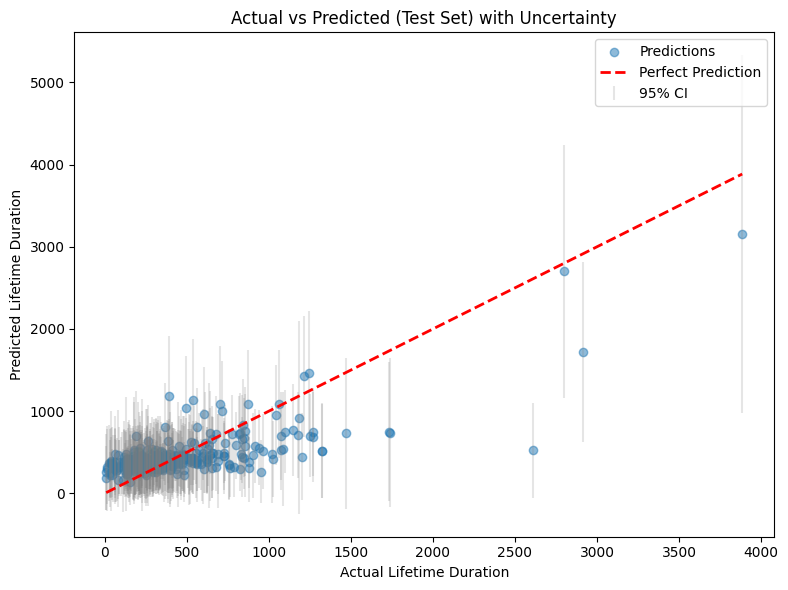

In [ ]:
### Uncertainty Modeling
# Get predictions with uncertainty
predictions_train = model.predict(X_train)
predictions_test = model.predict(X_test)

# Extract mean predictions and variance
y_pred_train = predictions_train[:, 0]
y_pred_test = predictions_test[:, 0]
variance_train = predictions_train[:, 1]
variance_test = predictions_test[:, 1]

# Calculate standard deviation and confidence intervals
std_train = np.sqrt(variance_train)
std_test = np.sqrt(variance_test)

# 95% confidence intervals
confidence_level = 1.96
lower_bound_test = y_pred_test - confidence_level * std_test
upper_bound_test = y_pred_test + confidence_level * std_test

print("\n=== UNCERTAINTY STATISTICS ===")
print(f"Mean Uncertainty (Test): {std_test.mean():.2f} days")
print(f"Median Uncertainty (Test): {np.median(std_test):.2f} days")
print(f"Min Uncertainty (Test): {std_test.min():.2f} days")
print(f"Max Uncertainty (Test): {std_test.max():.2f} days")


# Actual vs Predicted plot with uncertainty
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5, label='Predictions')
plt.errorbar(y_test, y_pred_test, yerr=confidence_level*std_test,
             fmt='none', alpha=0.2, color='gray', label='95% CI')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Lifetime Duration')
plt.ylabel('Predicted Lifetime Duration')
plt.title('Actual vs Predicted (Test Set) with Uncertainty')
plt.legend()
plt.tight_layout()
plt.show()

#Coverage test
predictions_test = model.predict(X_test)
y_pred_test = predictions_test[:, 0]
variance_test = predictions_test[:, 1]
std_test = np.sqrt(variance_test)
lower_bound = y_pred_test - 1.96 * std_test
upper_bound = y_pred_test + 1.96 * std_test
within_ci = (y_test >= lower_bound) & (y_test <= upper_bound)
coverage = within_ci.mean()
print(coverage)

Top Predictors
                feature  importance
14     chemgroup2_score   32.615306
0     GrossStrokeLength   11.238857
13     chemgroup1_score    8.367590
4     gas_anchor_length    8.198259
9     AVG_LIQUID_VOLUME    6.846329
7   AVG_PRESSURE_TUBING    6.550403
12           WaterRatio    5.673091
10          AVG_WATERSG    4.264776
8   AVG_PRESSURE_CASING    4.257456
3     bha_configuration    3.776309


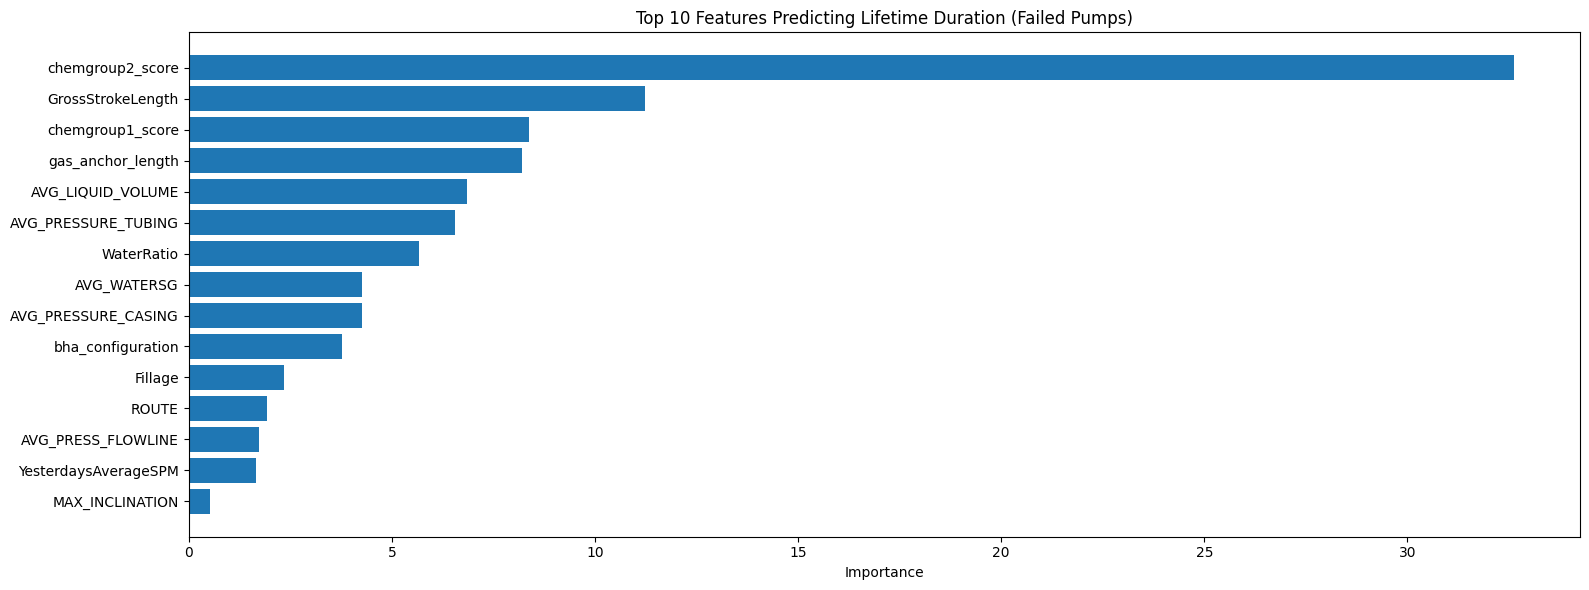

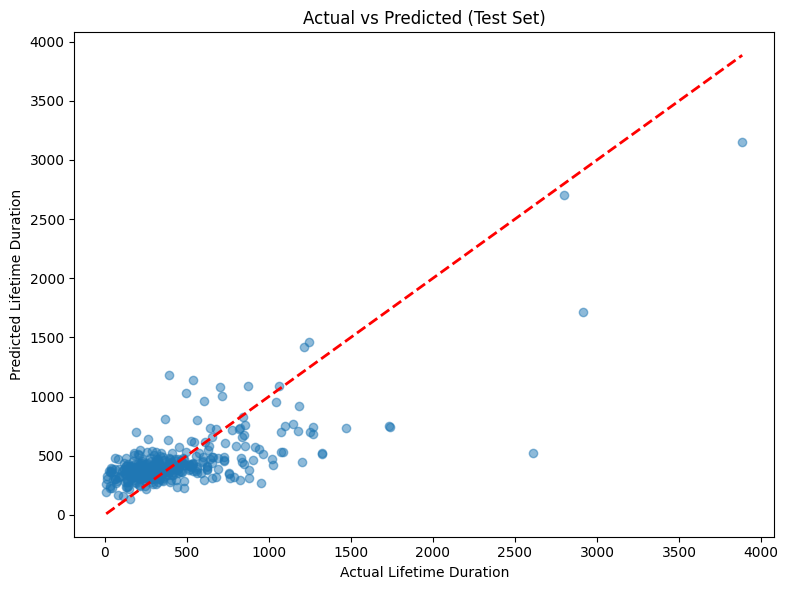

In [ ]:
### Feature importance
feature_importance = model.get_feature_importance()
importance_df = pd.DataFrame({
    'feature': X.columns.tolist(),
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Top Predictors")
print(importance_df.head(10))

# Visualize feature importance
plt.figure(figsize=(16, 6))
plt.barh(importance_df.head(16)['feature'], importance_df.head(16)['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Features Predicting Lifetime Duration (Failed Pumps)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Actual vs Predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Lifetime Duration')
plt.ylabel('Predicted Lifetime Duration')
plt.title('Actual vs Predicted (Test Set)')
plt.tight_layout()
plt.show()

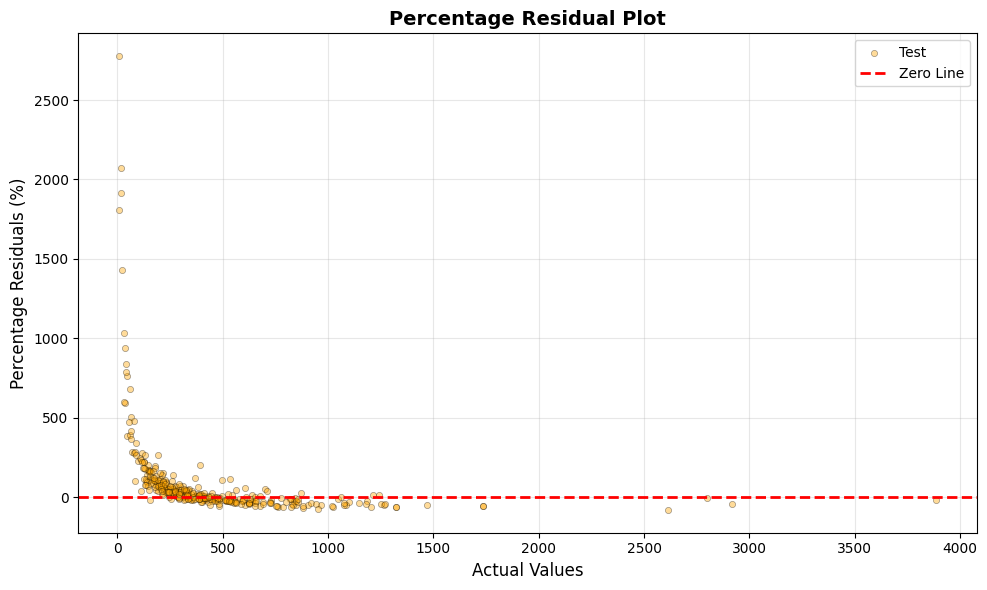

In [ ]:
### Percentage Residuals
# Calculate percentage residuals: (y_pred - y_true) / y_true * 100
def calculate_percentage_residuals(y_true, y_pred):
    """
    Calculate percentage residuals: ((y_pred - y_true) / y_true) * 100
    """
    # Avoid division by zero
    mask = y_true != 0
    percentage_residuals = np.zeros_like(y_true)
    percentage_residuals[mask] = ((y_pred[mask] - y_true[mask]) / y_true[mask]) * 100
    return percentage_residuals

# Calculate percentage residuals for test sets
perc_residuals_test = calculate_percentage_residuals(y_test, y_pred_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, perc_residuals_test, alpha=0.4, s=20, color='orange', label='Test', edgecolors='k', linewidths=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero Line')
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Percentage Residuals (%)', fontsize=12)
plt.title('Percentage Residual Plot', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
##### XGBoost (Generated with AI)

### Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

### Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/PandaKnee/Rod-Pump-Failure-Analysis/refs/heads/main/postFS_df.csv')

### Data preprocessing
# Filter censored data where failure occurred
df = df[df['FAILED'] == 1]

# Drop irrelevant or unnecessary columns
df.drop(['UWI', 'tbguid', 'lifetime_start', 'FAILURETYPE'], axis=1, inplace=True)

# Separate features and target
X = df.drop(['FAILED', 'lifetime_duration_days'], axis=1)
y = df['lifetime_duration_days']

# Identify categorical and numerical columns
cat_features = ['bha_configuration', 'ROUTE']  # Categorical column
num_features = list(set(X.columns) - set(cat_features))  # Remaining columns are numerical

# Stratify target for binning (optional for imbalanced target)
y_bins = pd.qcut(y, q=5, labels=False, duplicates='drop')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21, stratify=y_bins)

### Data transformation pipeline
# Define transformations for categorical and numerical features
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing categorical values
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))  # One-hot encode categorical data
])

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Handle missing numerical values
    ('scaler', StandardScaler())  # Scale numerical features
])

# Combine preprocessors into a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

### XGBoost Model Training
# Define an XGBoost model
xgb_model = XGBRegressor(
    n_estimators=2000,  # Number of boosting rounds
    learning_rate=0.03,  # Learning rate
    max_depth=4,  # Tree depth
    reg_lambda=10,  # L2 regularization
    random_state=21,  # For reproducibility
    verbosity=1
)

# Define entire pipeline (preprocessing + model)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Data preprocessing
    ('model', xgb_model)  # XGBoost regressor
])

# Fit the pipeline to the training data
pipeline.fit(X_train, y_train)

### Evaluate the model
# Make predictions
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Calculate evaluation metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

# Print metrics
print("\n=== MODEL PERFORMANCE ===")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Train MAE: {train_mae:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Train R²: {train_r2:.3f}")
print(f"Test R²: {test_r2:.3f}")


=== MODEL PERFORMANCE ===
Train RMSE: 88.90
Test RMSE: 284.42
Train MAE: 62.69
Test MAE: 196.99
Train R²: 0.951
Test R²: 0.540
